In [1]:
import torch
from torchvision import models

In [2]:
resnet = models.resnet101(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:01<00:00, 144MB/s]


In [3]:
resnet

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [4]:
from torchvision import transforms
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456,0.406],
        std = [0.299,0.224,0.225]
    )
])

In [6]:
from PIL import Image
img = Image.open("/content/download.jfif")
img.show()

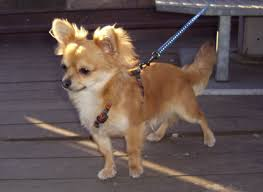

In [7]:
img

In [8]:
img_t = preprocess(img)

In [9]:
batch_t = torch.unsqueeze(img_t,0)

In [10]:
resnet.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [11]:
out = resnet(batch_t)

In [12]:
out

tensor([[ 4.3621e-01,  2.1126e+00, -2.4864e+00, -2.4595e+00, -1.3517e+00,
          2.5525e+00, -3.2325e+00, -1.6603e-01,  1.9704e+00, -2.1514e+00,
          7.2445e-01, -2.6743e-01, -3.3839e+00, -2.6441e+00, -2.6872e+00,
         -2.9100e+00, -4.2503e-01,  5.3726e-01, -2.6272e+00, -1.9489e+00,
         -3.2408e+00, -1.9625e+00, -3.8644e+00, -2.3496e+00, -3.8635e+00,
          6.6081e-01,  1.3353e+00,  6.6895e-01,  2.5680e-01,  3.1048e+00,
         -1.8052e+00, -5.2606e-01,  2.0087e+00, -1.3861e+00, -1.6814e+00,
         -2.6172e+00, -6.8322e-01, -1.3131e+00,  2.9100e+00, -2.1258e+00,
          1.4041e-01,  1.4313e+00,  3.8515e-01,  8.8183e-01,  1.6531e+00,
         -6.8688e-02, -1.1274e+00,  1.8501e+00, -3.6647e+00, -2.2629e+00,
         -2.8975e+00,  1.5518e+00, -1.5800e+00, -3.8026e+00, -1.9684e+00,
         -2.1941e+00, -1.7161e+00, -2.0404e+00, -1.4228e+00, -9.7987e-01,
          5.6700e-01, -3.3159e+00,  2.6936e-01, -5.0173e-01, -1.7450e+00,
         -1.1701e+00, -5.7521e-01, -9.

In [13]:
import requests

# URL of the ImageNet class labels file
labels_url = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"

# Download the file
response = requests.get(labels_url)
response.raise_for_status() # Raise an exception for bad status codes

# Save the file locally
with open("imagenet_classes.json", "w") as f:
    f.write(response.text)

print("Downloaded ImageNet class labels to imagenet_classes.json")

Downloaded ImageNet class labels to imagenet_classes.json


In [14]:
import json

# Load the labels from the JSON file
with open("imagenet_classes.json", "r") as f:
    imagenet_classes = json.load(f)

print(f"Loaded {len(imagenet_classes)} ImageNet class labels.")
# Display the first 10 labels as an example
print(imagenet_classes[:10])

Loaded 1000 ImageNet class labels.
['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead shark', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich']


In [15]:
_,index = torch.max(out,1)

In [17]:
percentage = torch.nn.functional.softmax(out , dim = 1)[0]*100
imagenet_classes[index[0]],percentage[index[0]].item()

('Chihuahua', 63.75865936279297)

In [18]:
_,indices = torch.sort(out,descending = True)
[(imagenet_classes[idx],percentage[idx].item()) for idx in indices[0][:5]]

[('Chihuahua', 63.75865936279297),
 ('Pomeranian', 30.459341049194336),
 ('Papillon', 1.4871187210083008),
 ('toy terrier', 1.1490137577056885),
 ('Pekingese', 0.7420996427536011)]

Processing image: /content/download.jfif


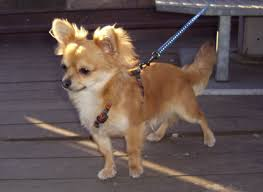

Top 5 predictions:
- Chihuahua: 63.76%
- Pomeranian: 30.46%
- Papillon: 1.49%
- toy terrier: 1.15%
- Pekingese: 0.74%


[('Chihuahua', 63.75865936279297),
 ('Pomeranian', 30.459341049194336),
 ('Papillon', 1.4871187210083008),
 ('toy terrier', 1.1490137577056885),
 ('Pekingese', 0.7420996427536011)]

In [19]:
import matplotlib.pyplot as plt
from IPython.display import display # Import display to show images in Colab

def predict_image(image_path):
    # 1. Load the image
    img = Image.open(image_path)
    print(f"Processing image: {image_path}")
    # 2. Display the image
    display(img)

    # 3. Preprocess the image
    img_t = preprocess(img)
    batch_t = torch.unsqueeze(img_t, 0)

    # 4. Set the model to evaluation mode and get predictions
    resnet.eval()
    out = resnet(batch_t)

    # 5. Calculate probabilities and get top 5 predictions
    percentage = torch.nn.functional.softmax(out, dim=1)[0] * 100
    _, indices = torch.sort(out, descending=True)

    top_5_predictions = [
        (imagenet_classes[idx], percentage[idx].item())
        for idx in indices[0][:5]
    ]

    print("Top 5 predictions:")
    for class_name, prob in top_5_predictions:
        print(f"- {class_name}: {prob:.2f}%")

    return top_5_predictions

# Example usage with the previously loaded image:
predict_image("/content/download.jfif")